In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from src.config import Configuration

CONFIG = Configuration()

# Example of all types of filters

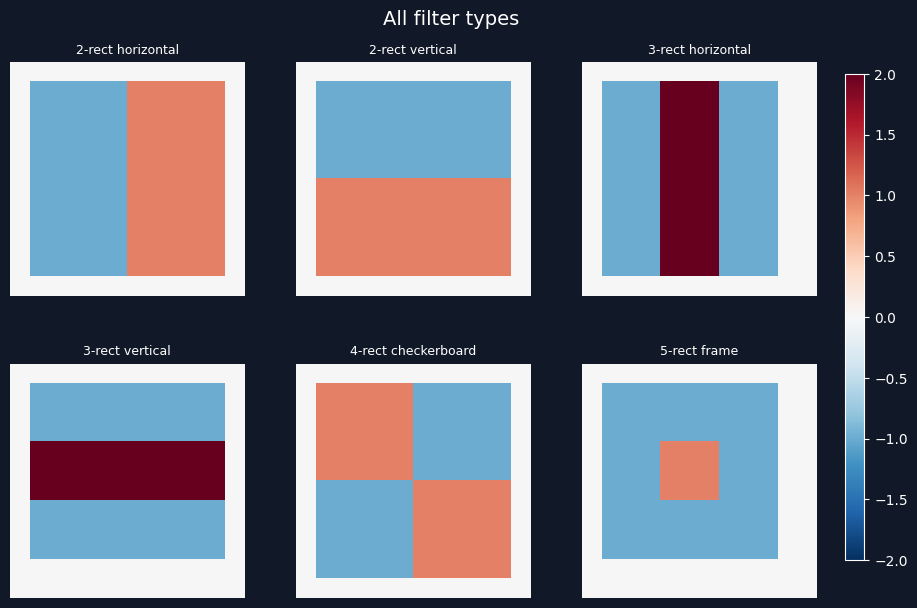

In [3]:
import math

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np

from src.data.features import generate_all_features


def feature_to_filter_map(feature, width, height):
    filter_map = np.zeros((height, width), dtype=np.float32)

    for rect in feature.rectangles:
        x0 = int(rect.x)
        y0 = int(rect.y)
        x1 = x0 + int(rect.width)
        y1 = y0 + int(rect.height)
        filter_map[y0:y1, x0:x1] += float(rect.weight)

    return filter_map


all_features = generate_all_features(win_w=24, win_h=24, include_square_features=True)

type_labels = [
    "2-rect horizontal",
    "2-rect vertical",
    "3-rect horizontal",
    "3-rect vertical",
    "4-rect checkerboard",
    "5-rect frame",
]

type_examples = []
seen = set()
for f in all_features:
    rects = f.rectangles
    t = len(rects)

    if t == 2:
        r1, r2 = rects
        if r1.width == r2.width and r1.x == r2.x:
            key = 1  # 2-rect vertical
        elif r1.height == r2.height and r1.y == r2.y:
            key = 0  # 2-rect horizontal
        elif r1.width == r1.height and r2.width == r2.height:
            key = 5  # frame (two squares)
        else:
            continue
    elif t == 3:
        r1, r2, r3 = rects
        if r1.height == r2.height == r3.height and r1.y == r2.y == r3.y:
            key = 2  # 3-rect horizontal
        else:
            key = 3  # 3-rect vertical
    elif t == 4:
        key = 4  # 4-rect checkerboard
    else:
        continue

    if key not in seen:
        seen.add(key)
        type_examples.append((key, f))
    else:
        idx = next(i for i, (k, _) in enumerate(type_examples) if k == key)
        old_area = type_examples[idx][1].rectangles[0].width * type_examples[idx][1].rectangles[0].height
        new_area = f.rectangles[0].width * f.rectangles[0].height
        if new_area > old_area:
            type_examples[idx] = (key, f)


n_filters = len(type_examples)
n_cols = min(4, max(1, int(math.ceil(math.sqrt(n_filters)))))
n_rows = int(math.ceil(n_filters / n_cols))

filter_maps = [feature_to_filter_map(f, 24, 24) for _, f in type_examples]
vmax = max(1e-9, max(float(np.max(np.abs(fm))) for fm in filter_maps))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

plt.close("all")
plt.style.use("dark_background")

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 3.2 * n_rows),
    squeeze=False,
)
fig.patch.set_facecolor("#111827")
fig.subplots_adjust(left=0.04, right=0.88, top=0.90, bottom=0.06, wspace=0.22, hspace=0.28)
fig.suptitle(
    "All filter types",
    fontsize=14,
    color="white",
)

for ax, (key, feat) in zip(axes.ravel(), type_examples):
    fm = feature_to_filter_map(feat, 24, 24)
    image = ax.imshow(
        fm,
        cmap="RdBu_r",
        norm=norm,
        interpolation="nearest",
    )
    ax.set_facecolor("#0f172a")
    ax.set_title(type_labels[key], fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.title.set_color("white")

cax = fig.add_axes([0.91, 0.12, 0.02, 0.76])
fig.colorbar(image, cax=cax)
cax.set_facecolor("#111827")

for ax in axes.ravel()[n_filters:]:
    ax.axis("off")

plt.show()

# Visualize filters

In [ ]:
import os
import glob
import re
from src.model import load_cascade, CascadeClassifier

model_dirs = {
    'no_pfp_99':      os.path.join(CONFIG.MODELS_PATH, 'haar_cascades_computed_best_balanced_99'),
    'no_pfp_999':     os.path.join(CONFIG.MODELS_PATH, 'haar_cascades_computed_best_balanced_999'),
    'pfp_99':  os.path.join(CONFIG.MODELS_PATH, 'haar_cascades_computed_best_balanced_pfp_99'),
    'pfp_999': os.path.join(CONFIG.MODELS_PATH, 'haar_cascades_computed_best_balanced_pfp_999'),
}

model_names = list(model_dirs.keys())

cascades = []
for name, dir_path in model_dirs.items():
    xml_files = glob.glob(os.path.join(dir_path, 'haar_cascade_stage_*.xml'))

    def extract_stage_num(fn):
        m = re.search(r'haar_cascade_stage_(\d+)_', fn)
        return int(m.group(1)) if m else 0

    xml_files.sort(key=extract_stage_num)
    cascade_path = xml_files[-1]
    cascade = load_cascade(cascade_path)
    CONFIG.crop_size = max(cascade.height, cascade.width)
    _ = CascadeClassifier(CONFIG, cascade)
    cascades.append(cascade)


Loading Haar cascade from: ../models/haar_cascades_computed_best_balanced_99/haar_cascade_stage_23_fpr_0.0000000000.xml
Loading Haar cascade from: ../models/haar_cascades_computed_best_balanced_999/haar_cascade_stage_28_fpr_0.0000000000.xml
Loading Haar cascade from: ../models/haar_cascades_computed_best_balanced_pfp_99/haar_cascade_stage_18_fpr_0.0000000000.xml
Loading Haar cascade from: ../models/haar_cascades_computed_best_balanced_pfp_999/haar_cascade_stage_21_fpr_0.0000000000.xml


In [9]:
import math

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
import numpy as np
import ipywidgets as widgets
from IPython.display import display


def feature_to_filter_map(feature, width, height):
    filter_map = np.zeros((height, width), dtype=np.float32)

    for rect in feature.rectangles:
        x0 = int(rect.x)
        y0 = int(rect.y)
        x1 = x0 + int(rect.width)
        y1 = y0 + int(rect.height)
        filter_map[y0:y1, x0:x1] += float(rect.weight)

    return filter_map


def extract_stage_filters(cascade):
    stages = []

    for stage in cascade.stages:
        filters = []

        for classifier in stage.weak_classifiers:
            if classifier.feature is None:
                continue

            filters.append(
                {
                    "classifier_id": classifier.classifier_id,
                    "feature_id": classifier.feature_id,
                    "threshold": float(classifier.threshold),
                    "left_value": float(classifier.left_value),
                    "right_value": float(classifier.right_value),
                    "rectangles": [
                        {
                            "x": int(rect.x),
                            "y": int(rect.y),
                            "width": int(rect.width),
                            "height": int(rect.height),
                            "weight": float(rect.weight),
                        }
                        for rect in classifier.feature.rectangles
                    ],
                    "filter_map": feature_to_filter_map(
                        classifier.feature,
                        width=cascade.width,
                        height=cascade.height,
                    ),
                }
            )

        stages.append(
            {
                "stage_id": stage.stage_id,
                "threshold": float(stage.threshold),
                "max_weak_count": stage.max_weak_count,
                "filters": filters,
            }
        )

    return {
        "cascade_type": cascade.cascade_type,
        "feature_type": cascade.feature_type,
        "width": cascade.width,
        "height": cascade.height,
        "stage_count": len(stages),
        "stages": stages,
    }


all_stage_filters = [extract_stage_filters(c) for c in cascades]
max_stage_count = max(sf["stage_count"] for sf in all_stage_filters)


def plot_stage(stage_index):
    plt.close("all")
    plt.style.use("dark_background")

    model_filters = []
    model_titles = []
    max_filters = 0

    for i, sf in enumerate(all_stage_filters):
        if stage_index < sf["stage_count"]:
            stage = sf["stages"][stage_index]
            filters = stage["filters"]
            model_filters.append(filters)
            max_filters = max(max_filters, len(filters))
            model_titles.append(
                f"{model_names[i]}\n"
                f"Stage {stage['stage_id']} | "
                f"th={stage['threshold']:.4f} | "
                f"{len(filters)} filters"
            )
        else:
            model_filters.append([])
            model_titles.append(f"{model_names[i]}\n(no more stages)")

    n_models = len(all_stage_filters)

    if max_filters == 0:
        fig, ax = plt.subplots(figsize=(3.2 * n_models, 1))
        fig.patch.set_facecolor("#111827")
        ax.axis("off")
        ax.text(
            0.5, 0.5, "No filters in any model at this stage",
            ha="center", va="center", color="white", fontsize=12,
            transform=ax.transAxes,
        )
        plt.show()
        return

    n_rows = 1 + max_filters
    height_ratios = [0.06] + [1.0] * max_filters

    fig = plt.figure(figsize=(4.0 * n_models, 3.2 * max_filters + 0.3))
    fig.patch.set_facecolor("#111827")
    gs = GridSpec(
        n_rows, n_models, figure=fig,
        height_ratios=height_ratios,
        left=0.04, right=0.93, top=0.99, bottom=0.04,
        wspace=0.18, hspace=0.06,
    )

    global_vmax = max(
        max(
            (float(np.max(np.abs(item["filter_map"]))) for item in f),
            default=1e-9,
        )
        for f in model_filters
    )
    global_vmax = max(1e-9, global_vmax)
    norm = TwoSlopeNorm(vmin=-global_vmax, vcenter=0.0, vmax=global_vmax)

    for col_idx in range(n_models):
        title_ax = fig.add_subplot(gs[0, col_idx])
        title_ax.axis("off")
        title_ax.set_title(model_titles[col_idx], fontsize=9, color="white", pad=2)

        filters = model_filters[col_idx]

        for row_idx in range(max_filters):
            ax = fig.add_subplot(gs[row_idx + 1, col_idx])
            ax.set_facecolor("#0f172a")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

            if row_idx < len(filters):
                item = filters[row_idx]
                image = ax.imshow(
                    item["filter_map"],
                    cmap="RdBu_r",
                    norm=norm,
                    interpolation="nearest",
                )
                ax.set_title(
                    f"clf {item['classifier_id']} | feat {item['feature_id']}",
                    fontsize=6,
                    color="white",
                )
            else:
                ax.axis("off")

    cax = fig.add_axes([0.95, 0.08, 0.015, 0.84])
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="RdBu_r"), cax=cax)
    cax.set_facecolor("#111827")

    plt.show()


stage_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, max_stage_count - 1),
    step=1,
    description="Stage",
    continuous_update=False,
)

stage_output = widgets.interactive_output(plot_stage, {"stage_index": stage_slider})
display(widgets.VBox([stage_slider, stage_output]))


## How to read the colors

These filter images use a diverging colormap centered at **0**.

- **Blue tones**: negative rectangle contribution (subtracts from the feature response).
- **Red tones**: positive rectangle contribution (adds to the feature response).
- **Near white / very light**: value close to zero (little or no contribution).
- **Darker, more saturated color**: larger absolute contribution (stronger effect).

So intensity means **strength**, and color hue (red vs blue) means **direction** (add vs subtract).

In [6]:
from IPython.display import display, Markdown, HTML

rows = []
for i, sf in enumerate(all_stage_filters):
    name = model_names[i]
    counts = [len(stage["filters"]) for stage in sf["stages"]]
    total = sum(counts)
    rows.append((name, counts, total))

header_html = "<tr><th>Model</th>"
for si in range(max_stage_count):
    header_html += f"<th>S{si}</th>"
header_html += "<th>TOTAL</th></tr>"

body_html = ""
for name, counts, total in rows:
    body_html += f"<tr><td><b>{name}</b></td>"
    for si in range(max_stage_count):
        if si < len(counts):
            body_html += f"<td>{counts[si]}</td>"
        else:
            body_html += f"<td style='color:#555'>-</td>"
    body_html += f"<td><b>{total}</b></td></tr>"

display(Markdown("### Filters per stage"))
display(HTML(
    f"<table style='border-collapse:collapse;margin:1em 0'>"
    f"{header_html}{body_html}"
    f"</table>"
))


### Filters per stage

Model,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,S15,S16,S17,S18,S19,S20,S21,S22,S23,S24,S25,S26,S27,TOTAL
999,4,6,8,11,15,24,30,38,44,56,70,76,93,112,128,141,157,187,202,222,256,284,330,346,367,419,475,500,4601
99,2,5,5,8,6,12,15,23,26,36,37,40,54,62,67,77,90,93,123,125,141,157,178,-,-,-,-,-,1382
pfp_99,4,10,13,22,39,36,47,56,68,87,84,91,98,112,133,137,159,178,-,-,-,-,-,-,-,-,-,-,1374
pfp_999,7,23,38,59,86,85,109,133,155,181,186,218,225,246,302,317,355,395,414,452,500,-,-,-,-,-,-,-,4486
